In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv("Salary_Data.csv")

In [3]:
data.head()

,YearsExperience,Salary
0,1.1,39343
1,1.3,46205
2,1.5,37731
3,2.0,43525
4,2.2,39891


In [5]:
data.shape

(30, 2)

In [6]:
data.isnull().sum()

YearsExperience    0
Salary             0
dtype: int64

In [7]:
x = data.iloc[: , :-1].values
y = data.iloc[:,1].values

In [8]:
x

array([[ 1.1],
       [ 1.3],
       [ 1.5],
       [ 2. ],
       [ 2.2],
       [ 2.9],
       [ 3. ],
       [ 3.2],
       [ 3.2],
       [ 3.7],
       [ 3.9],
       [ 4. ],
       [ 4. ],
       [ 4.1],
       [ 4.5],
       [ 4.9],
       [ 5.1],
       [ 5.3],
       [ 5.9],
       [ 6. ],
       [ 6.8],
       [ 7.1],
       [ 7.9],
       [ 8.2],
       [ 8.7],
       [ 9. ],
       [ 9.5],
       [ 9.6],
       [10.3],
       [10.5]])

In [9]:
y

array([ 39343,  46205,  37731,  43525,  39891,  56642,  60150,  54445,
        64445,  57189,  63218,  55794,  56957,  57081,  61111,  67938,
        66029,  83088,  81363,  93940,  91738,  98273, 101302, 113812,
       109431, 105582, 116969, 112635, 122391, 121872], dtype=int64)

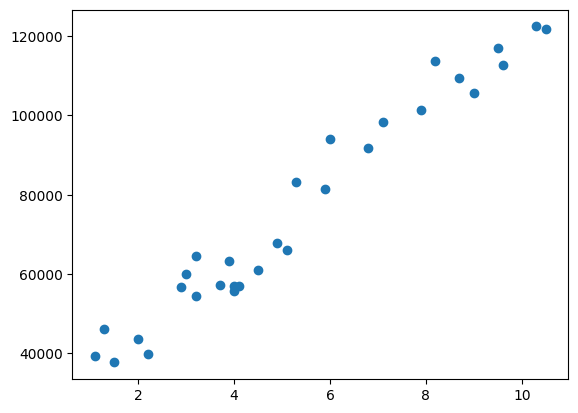

In [10]:
plt.scatter(x,y)
plt.show()

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [13]:
x_train , x_test , y_train , y_test = train_test_split(x, y , test_size = 0.3 , random_state = 0)

In [14]:
model = LinearRegression()

In [15]:
model.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [16]:
y_pred = model.predict(x_test)

In [17]:
y_pred

array([ 40817.78327049, 123188.08258899,  65154.46261459,  63282.41035735,
       115699.87356004, 108211.66453108, 116635.89968866,  64218.43648597,
        76386.77615802])

In [18]:
r2_score(y_pred , y_test)

0.9710122289422968

In [19]:
model.predict([[11]])

array([129740.26548933])

In [21]:
import joblib

In [22]:
joblib.dump(model , "Salary_predication_model.pkl")

['Salary_predication_model.pkl']

In [23]:
load_model = joblib.load("Salary_predication_model.pkl")
load_model.predict([[13]])

array([148460.78806172])

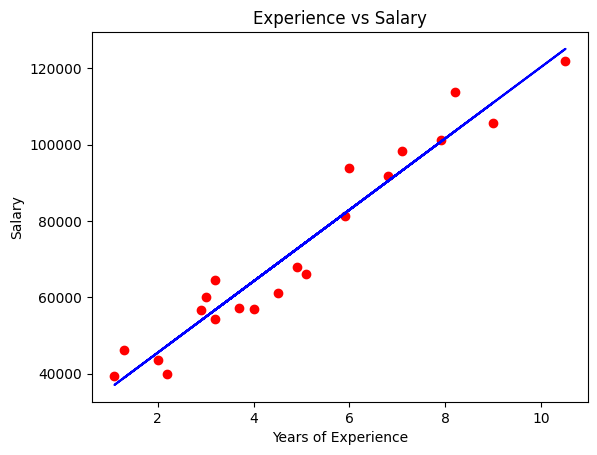

In [24]:
# Scatter plot (actual data)
plt.scatter(x_train, y_train, color='red')

# Regression line (predicted)
plt.plot(x_train, model.predict(x_train), color='blue')

plt.title("Experience vs Salary")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")

plt.show()